#  Análisis Exploratorio de Datos - Wisconsin Breast Cancer Dataset
 
Este notebook realiza un análisis completo del dataset de cáncer de mama de Wisconsin, incluyendo:
- Carga y limpieza de datos
- Estadísticas descriptivas
- Visualización de distribuciones
- Matriz de correlación
- Detección de outliers
- Diagrama de caja y bigotes

## 1. Importación de librerías


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
# Configuración de visualización
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 180

## 2. Carga de datos y limpieza


In [41]:
# Cargar datos
df = pd.read_csv("Datos.csv")

print("=== PRIMERAS FILAS ===")
print(df.head())

print("\n=== INFORMACIÓN DEL DATASET ===")
print(df.info())

# Eliminar columna de código de muestra si existe
if "Sample code number" in df.columns:
    df = df.drop(columns=["Sample code number"])
    print("\n✓ Columna 'Sample code number' eliminada")

# Separar features de la variable objetivo
if "Class" in df.columns:
    features = df.drop(columns=["Class"])
    target = df["Class"]
    print(f"\n✓ Variable objetivo 'Class' identificada")
    print(f"  Clases: 2 = Benigno, 4 = Maligno")
    print(f"  Distribución:\n{target.value_counts()}")
else:
    features = df
    target = None
    print("\nNo se encontró variable 'Class'")

=== PRIMERAS FILAS ===
   Sample code number  Clump Thickness  Uniformity of Cell Size  \
0             1000025                5                        1   
1             1002945                5                        4   
2             1015425                3                        1   
3             1016277                6                        8   
4             1017023                4                        1   

   Uniformity of Cell Shape  Marginal Adhesion  Single Epithelial Cell Size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

   Bare Nuclei  Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0            1                3 

 El dataset presenta un desbalance hacia la clase benigna (2), lo que debe considerarse en modelos posteriores.


In [42]:
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(features.describe())


=== ESTADÍSTICAS DESCRIPTIVAS ===
       Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
count       683.000000               683.000000                683.000000   
mean          4.442167                 3.150805                  3.215227   
std           2.820761                 3.065145                  2.988581   
min           1.000000                 1.000000                  1.000000   
25%           2.000000                 1.000000                  1.000000   
50%           4.000000                 1.000000                  1.000000   
75%           6.000000                 5.000000                  5.000000   
max          10.000000                10.000000                 10.000000   

       Marginal Adhesion  Single Epithelial Cell Size  Bare Nuclei  \
count         683.000000                   683.000000   683.000000   
mean            2.830161                     3.234261     3.544656   
std             2.864562                     2.223085     3.6

## 3. Distribuciones por variable


=== VISUALIZANDO DISTRIBUCIONES ===


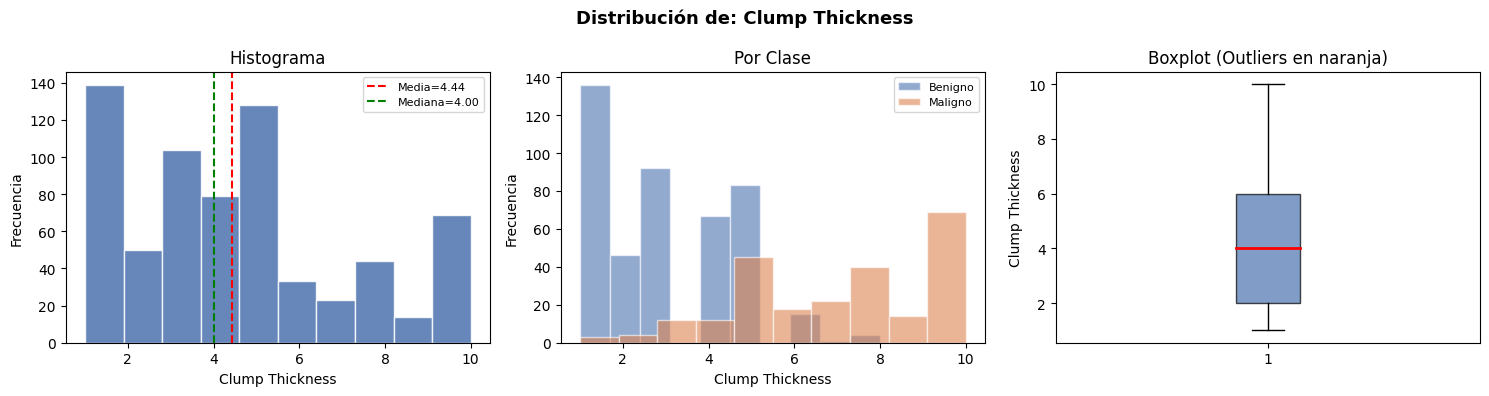

Mostrando distribución: Clump Thickness



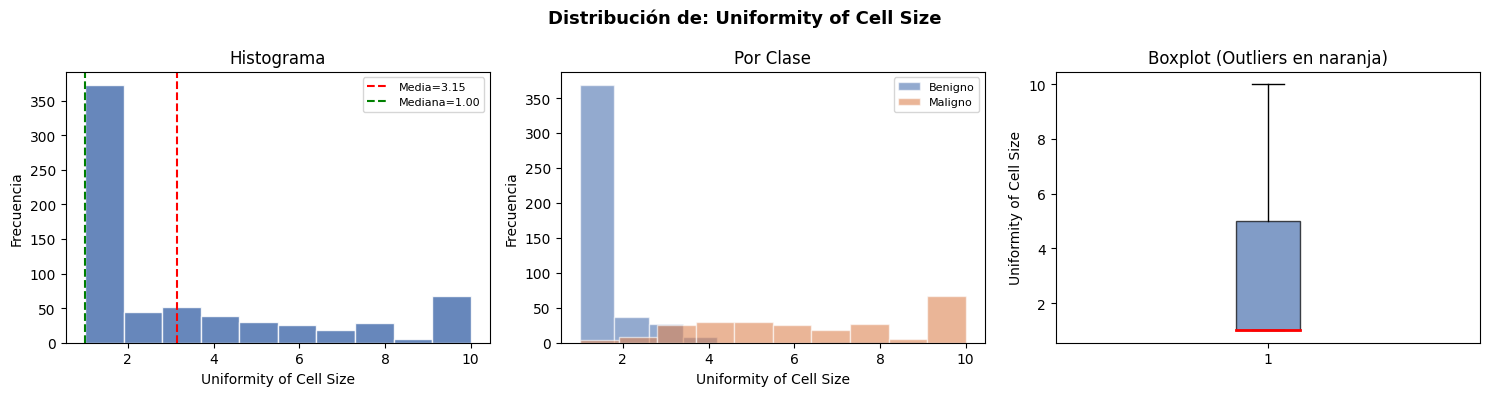

Mostrando distribución: Uniformity of Cell Size



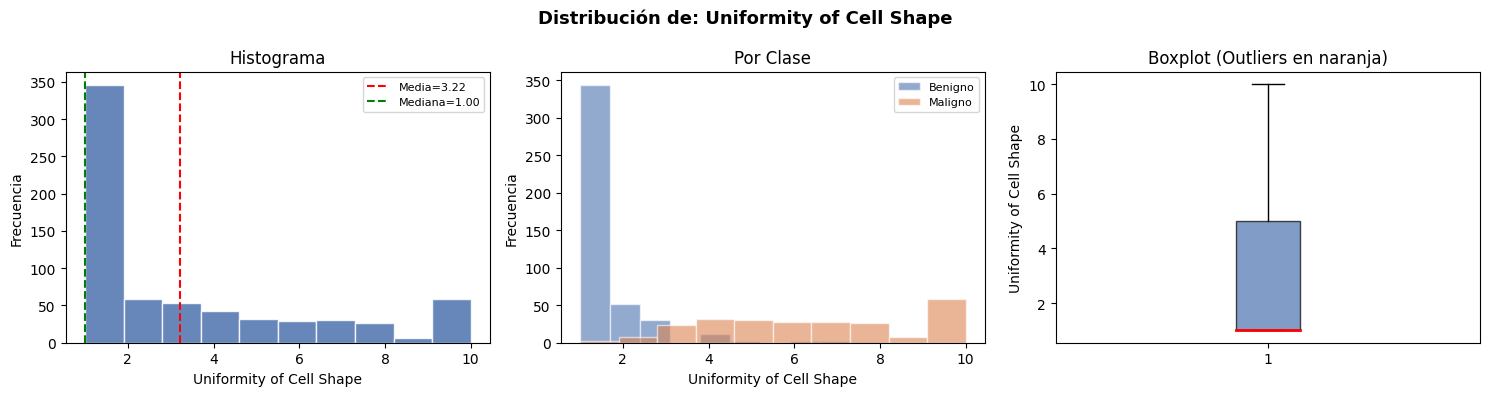

Mostrando distribución: Uniformity of Cell Shape



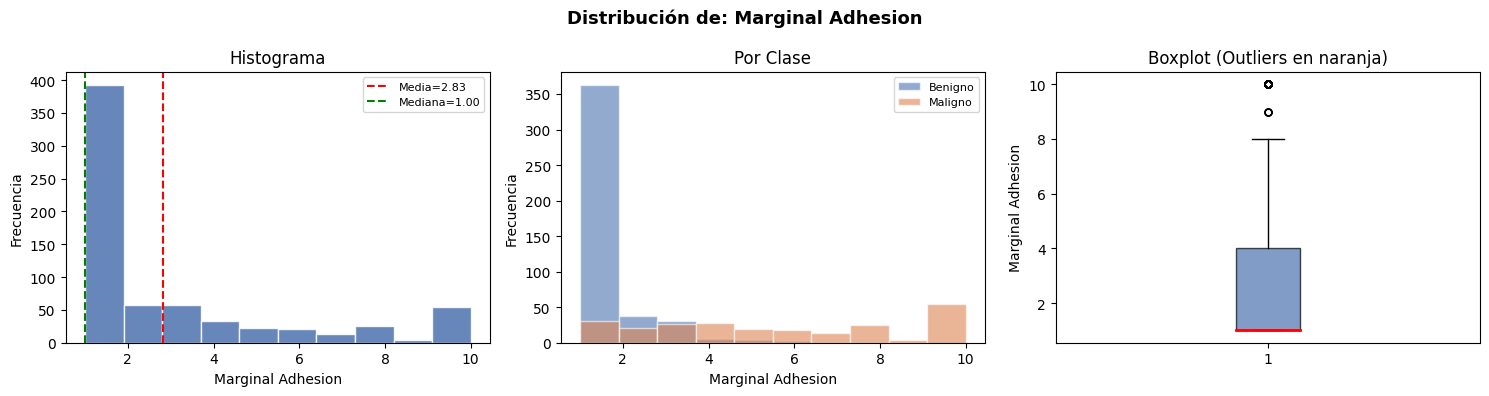

Mostrando distribución: Marginal Adhesion



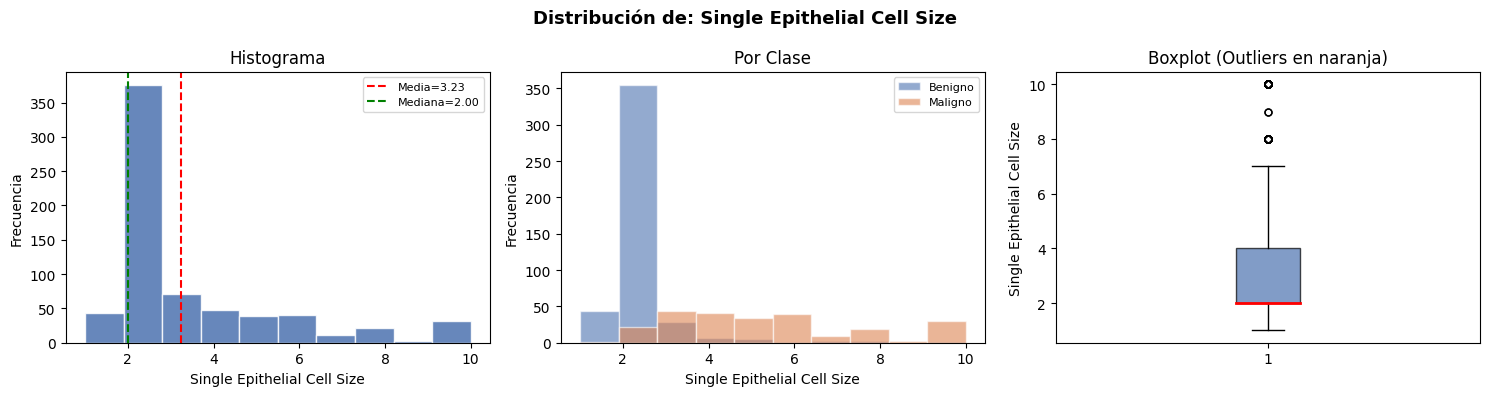

Mostrando distribución: Single Epithelial Cell Size



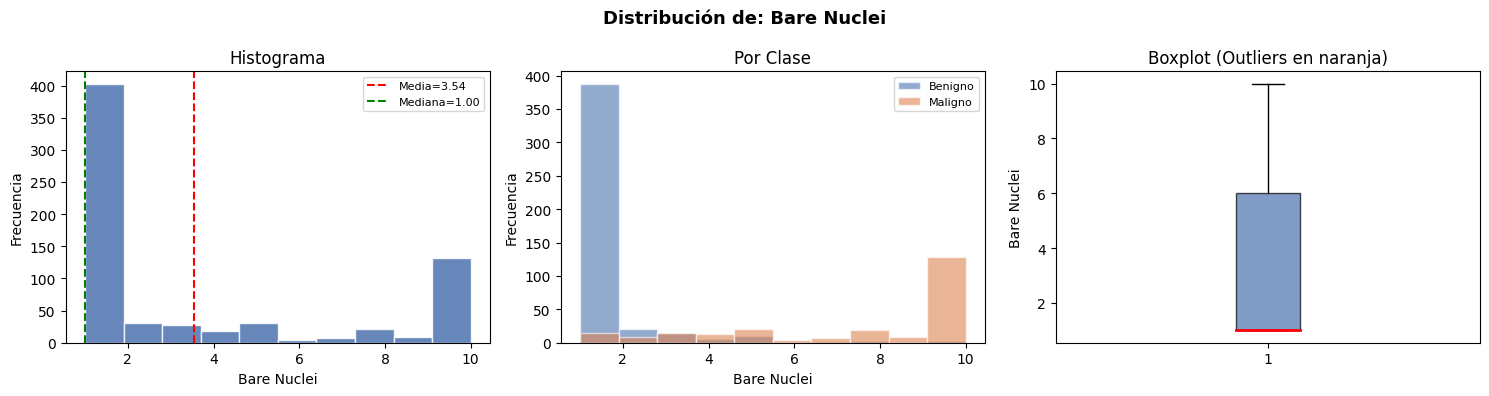

Mostrando distribución: Bare Nuclei



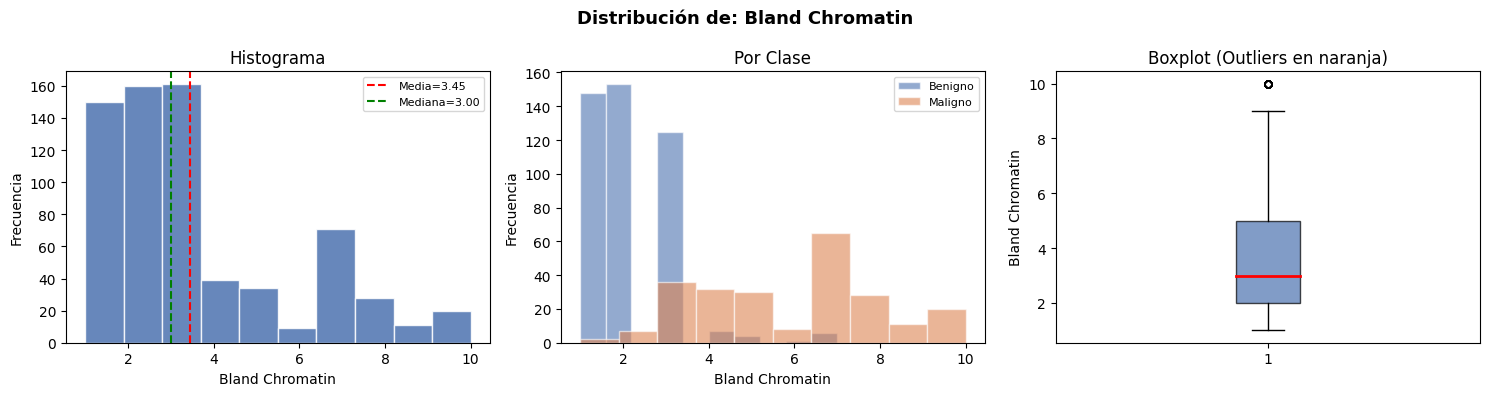

Mostrando distribución: Bland Chromatin



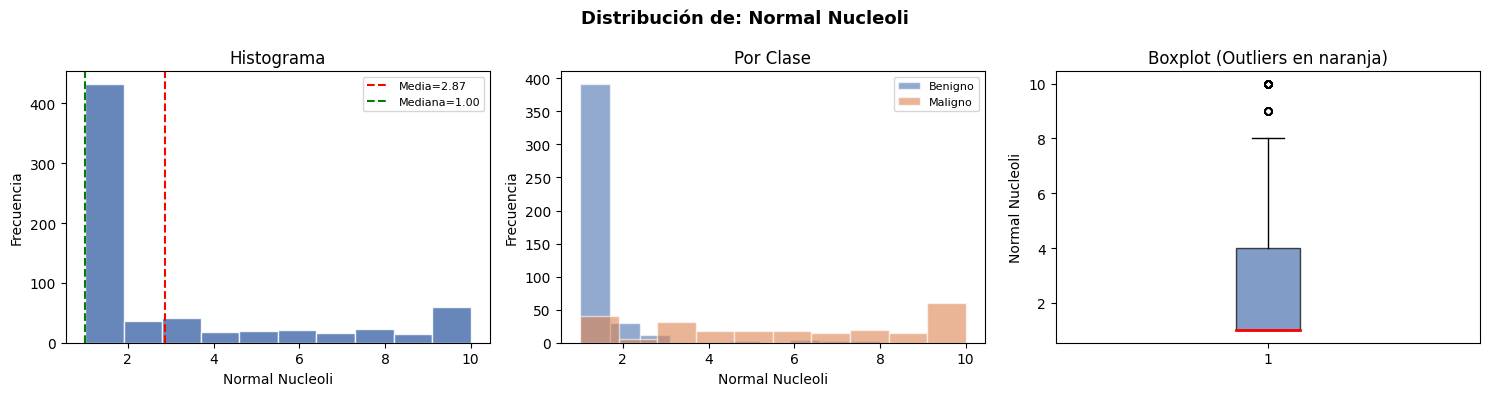

Mostrando distribución: Normal Nucleoli



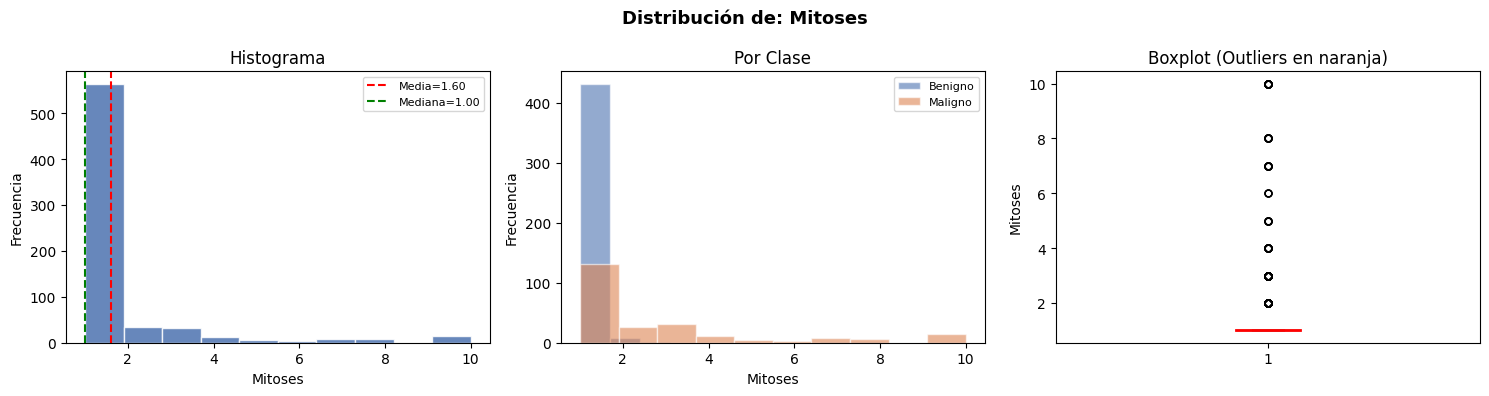

Mostrando distribución: Mitoses



In [43]:
print("\n=== VISUALIZANDO DISTRIBUCIONES ===")

for col in features.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Distribución de: {col}", fontsize=13, fontweight="bold")

    # --- Histograma con KDE ---
    ax1 = axes[0]
    ax1.hist(features[col], bins=10, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax1.set_title("Histograma")
    ax1.set_xlabel(col)
    ax1.set_ylabel("Frecuencia")

    # Estadísticas en el histograma
    mean_val = features[col].mean()
    median_val = features[col].median()
    ax1.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Media={mean_val:.2f}")
    ax1.axvline(median_val, color="green", linestyle="--", linewidth=1.5, label=f"Mediana={median_val:.2f}")
    ax1.legend(fontsize=8)

    # --- Distribución por clase (si hay target) ---
    ax2 = axes[1]
    if target is not None:
        for cls, color, label in zip([2, 4], ["#4C72B0", "#DD8452"], ["Benigno", "Maligno"]):
            subset = features.loc[target == cls, col]
            ax2.hist(subset, bins=10, alpha=0.6, color=color, edgecolor="white", label=label)
        ax2.set_title("Por Clase")
        ax2.set_xlabel(col)
        ax2.set_ylabel("Frecuencia")
        ax2.legend(fontsize=8)
    else:
        ax2.set_visible(False)

    # --- Boxplot ---
    ax3 = axes[2]
    bp = ax3.boxplot(features[col].dropna(), patch_artist=True,
                     boxprops=dict(facecolor="#4C72B0", alpha=0.7),
                     medianprops=dict(color="red", linewidth=2),
                     flierprops=dict(marker="o", color="orange", markersize=5))
    ax3.set_title("Boxplot (Outliers en naranja)")
    ax3.set_ylabel(col)

    plt.tight_layout()
    plt.show()
    print(f"Mostrando distribución: {col}\n")


Las distribuciones muestran un sesgo hacia la izquierda (valores bajos), lo cual es esperable en un dataset médico donde la mayoría de los casos son benignos.

## 4. Matriz de correlación


=== MATRIZ DE CORRELACIÓN ===
                             Clump Thickness  Uniformity of Cell Size  \
Clump Thickness                         1.00                     0.64   
Uniformity of Cell Size                 0.64                     1.00   
Uniformity of Cell Shape                0.65                     0.91   
Marginal Adhesion                       0.49                     0.71   
Single Epithelial Cell Size             0.52                     0.75   
Bare Nuclei                             0.59                     0.69   
Bland Chromatin                         0.55                     0.76   
Normal Nucleoli                         0.53                     0.72   
Mitoses                                 0.35                     0.46   

                             Uniformity of Cell Shape  Marginal Adhesion  \
Clump Thickness                                  0.65               0.49   
Uniformity of Cell Size                          0.91               0.71   
Uniformity

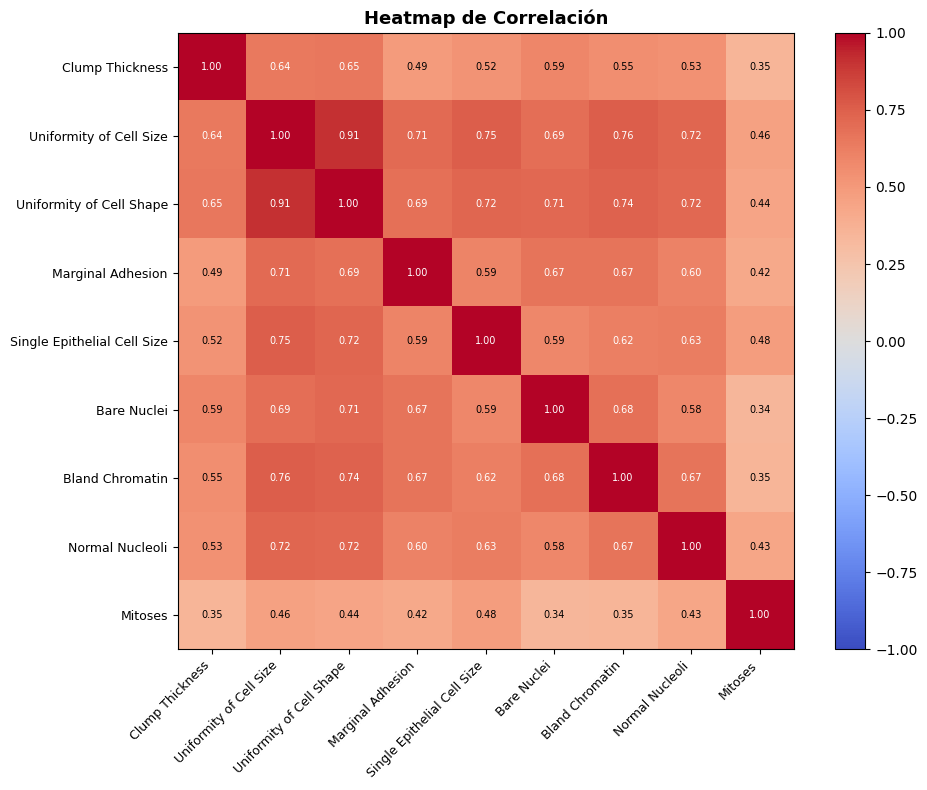


=== PARES CON ALTA CORRELACIÓN (>0.7) ===
  Uniformity of Cell Size ↔ Uniformity of Cell Shape: 0.907
  Uniformity of Cell Size ↔ Marginal Adhesion: 0.707
  Uniformity of Cell Size ↔ Single Epithelial Cell Size: 0.754
  Uniformity of Cell Size ↔ Bland Chromatin: 0.756
  Uniformity of Cell Size ↔ Normal Nucleoli: 0.719
  Uniformity of Cell Shape ↔ Single Epithelial Cell Size: 0.722
  Uniformity of Cell Shape ↔ Bare Nuclei: 0.714
  Uniformity of Cell Shape ↔ Bland Chromatin: 0.735
  Uniformity of Cell Shape ↔ Normal Nucleoli: 0.718

Matriz de correlación guardada en 'correlacion.csv'


In [44]:
print("\n=== MATRIZ DE CORRELACIÓN ===")

corr_matrix = features.corr()
print(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

n = len(corr_matrix.columns)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)

# Agregar valores numéricos
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.6 else "black")

ax.set_title("Heatmap de Correlación", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Pares de alta correlación
print("\n=== PARES CON ALTA CORRELACIÓN (>0.7) ===")
high_corr = []
for i in range(n):
    for j in range(i+1, n):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

if not high_corr:
    print("  No se encontraron correlaciones > 0.7")

# Guardar matriz (opcional)
corr_matrix.to_csv("correlacion.csv")
print("\nMatriz de correlación guardada en 'correlacion.csv'")


 ## 5. Detección detallada de outliers

In [45]:
print("\n=== DETECCIÓN DETALLADA DE OUTLIERS ===")

outliers_summary = {}

for col in features.columns:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_mask = (features[col] < lower_bound) | (features[col] > upper_bound)
    outliers_vals = features.loc[outliers_mask, col]

    pct = (outliers_mask.sum() / len(features)) * 100

    outliers_summary[col] = {
        "count": outliers_mask.sum(),
        "pct": round(pct, 2),
        "Q1": round(Q1, 3),
        "Q3": round(Q3, 3),
        "IQR": round(IQR, 3),
        "lower_bound": round(lower_bound, 3),
        "upper_bound": round(upper_bound, 3),
        "min_outlier": round(outliers_vals.min(), 3) if len(outliers_vals) > 0 else "N/A",
        "max_outlier": round(outliers_vals.max(), 3) if len(outliers_vals) > 0 else "N/A",
        "skewness": round(stats.skew(features[col].dropna()), 3),
        "kurtosis": round(stats.kurtosis(features[col].dropna()), 3),
    }

    print(f"\n  {col}:")
    print(f"    Outliers: {outliers_mask.sum()} ({pct:.1f}%)")
    print(f"    Rango IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"    Sesgo (skewness): {outliers_summary[col]['skewness']}")
    print(f"    Curtosis: {outliers_summary[col]['kurtosis']}")

# Guardar resumen detallado
outliers_df = pd.DataFrame(outliers_summary).T.reset_index()
outliers_df.columns = ["Variable"] + list(outliers_df.columns[1:])
outliers_df.to_csv("outliers_detallado.csv", index=False)
print("\n✓ Resumen de outliers guardado en 'outliers_detallado.csv'")



=== DETECCIÓN DETALLADA DE OUTLIERS ===

  Clump Thickness:
    Outliers: 0 (0.0%)
    Rango IQR: [-4.00, 12.00]
    Sesgo (skewness): 0.586
    Curtosis: -0.637

  Uniformity of Cell Size:
    Outliers: 0 (0.0%)
    Rango IQR: [-5.00, 11.00]
    Sesgo (skewness): 1.224
    Curtosis: 0.064

  Uniformity of Cell Shape:
    Outliers: 0 (0.0%)
    Rango IQR: [-5.00, 11.00]
    Sesgo (skewness): 1.155
    Curtosis: -0.025

  Marginal Adhesion:
    Outliers: 59 (8.6%)
    Rango IQR: [-3.50, 8.50]
    Sesgo (skewness): 1.506
    Curtosis: 0.927

  Single Epithelial Cell Size:
    Outliers: 54 (7.9%)
    Rango IQR: [-1.00, 7.00]
    Sesgo (skewness): 1.7
    Curtosis: 2.105

  Bare Nuclei:
    Outliers: 0 (0.0%)
    Rango IQR: [-6.50, 13.50]
    Sesgo (skewness): 0.988
    Curtosis: -0.802

  Bland Chromatin:
    Outliers: 20 (2.9%)
    Rango IQR: [-2.50, 9.50]
    Sesgo (skewness): 1.093
    Curtosis: 0.158

  Normal Nucleoli:
    Outliers: 75 (11.0%)
    Rango IQR: [-3.50, 8.50]
    Sesgo 

## 6. Gráfico resumen de outliers


C:\Users\olivi\AppData\Local\Temp\ipykernel_4152\4028467694.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(cols, rotation=35, ha="right")


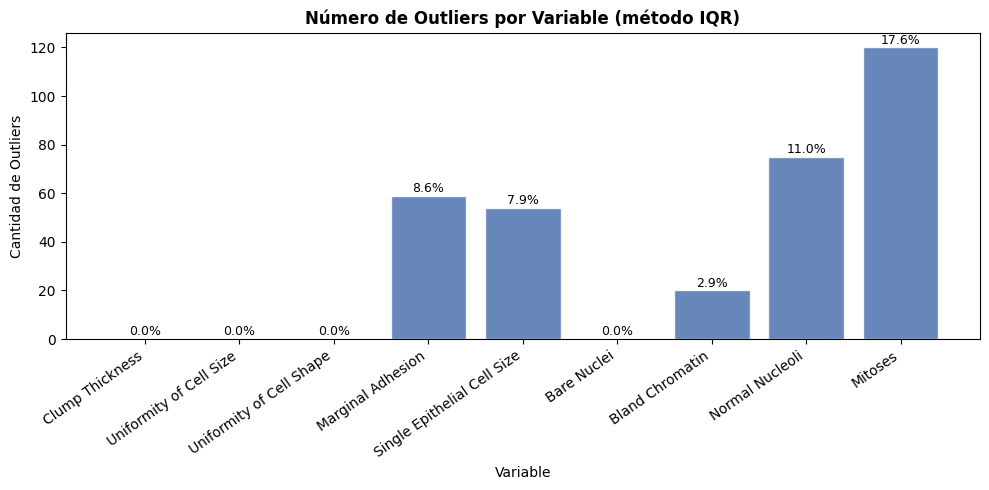


=== MOSTRANDO DIAGRAMA DE CAJA COMPLETO ===


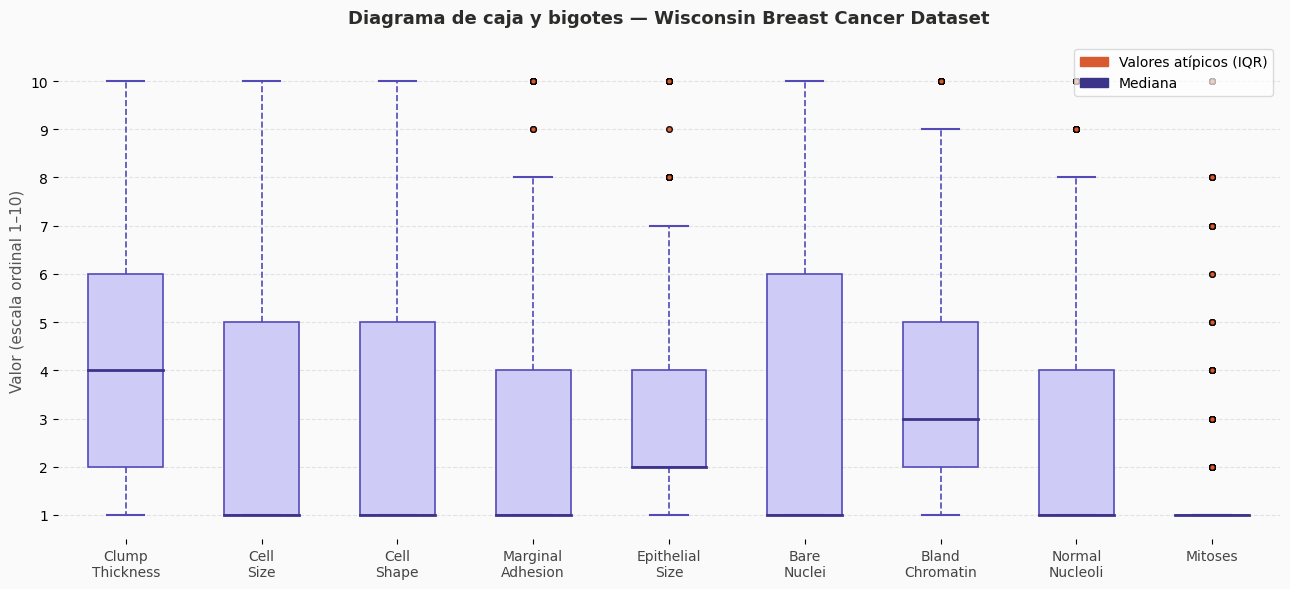

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
cols = list(outliers_summary.keys())
counts = [outliers_summary[c]["count"] for c in cols]
pcts = [outliers_summary[c]["pct"] for c in cols]

bars = ax.bar(cols, counts, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("Número de Outliers por Variable (método IQR)", fontsize=12, fontweight="bold")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad de Outliers")
ax.set_xticklabels(cols, rotation=35, ha="right")

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Diagrama de caja y bigotes completo

# %%
print("\n=== MOSTRANDO DIAGRAMA DE CAJA COMPLETO ===")

# Preparar datos para el boxplot
variables = features.columns.tolist()

# Nombres formateados para las variables
labels = [
    "Clump\nThickness", "Cell\nSize", "Cell\nShape",
    "Marginal\nAdhesion", "Epithelial\nSize", "Bare\nNuclei",
    "Bland\nChromatin", "Normal\nNucleoli", "Mitoses"
]

# Crear figura
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# Crear boxplot
bp = ax.boxplot(
    [features[col].dropna() for col in variables],
    patch_artist=True,
    notch=False,
    vert=True,
    widths=0.55,
    flierprops=dict(marker='o', color='#D85A30', markerfacecolor='#D85A30',
                    markersize=4, linestyle='none', alpha=0.7),
    medianprops=dict(color='#3C3489', linewidth=2),
    boxprops=dict(facecolor='#CECBF6', color='#534AB7', linewidth=1.2),
    whiskerprops=dict(color='#534AB7', linewidth=1.2, linestyle='--'),
    capprops=dict(color='#534AB7', linewidth=1.5),
)

# Configurar ejes
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=10, color='#444')
ax.set_yticks(range(1, 11))
ax.set_ylabel("Valor (escala ordinal 1–10)", fontsize=11, color='#555')
ax.set_ylim(0.5, 10.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#ccc')
ax.set_axisbelow(True)

# Ocultar spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Agregar leyenda
outlier_patch = mpatches.Patch(color='#D85A30', label='Valores atípicos (IQR)')
median_line = mpatches.Patch(color='#3C3489', label='Mediana')
ax.legend(handles=[outlier_patch, median_line], fontsize=10,
          loc='upper right', framealpha=0.7)

# Título
ax.set_title("Diagrama de caja y bigotes — Wisconsin Breast Cancer Dataset",
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)

plt.tight_layout()
plt.show()

## 8. Resumen final

In [47]:
print("\n" + "="*50)
print("=== ANÁLISIS COMPLETADO EXITOSAMENTE ===")
print("="*50)

# Mostrar estadísticas finales
print("\n=== ESTADÍSTICAS FINALES ===")
print(f"Total de registros: {len(features)}")
print(f"Total de variables: {len(features.columns)}")
if target is not None:
    print(f"Clases: Benignas = {(target == 2).sum()}, Malignas = {(target == 4).sum()}")
    print(f"Porcentaje benignos: {((target == 2).sum() / len(target)) * 100:.1f}%")
    print(f"Porcentaje malignos: {((target == 4).sum() / len(target)) * 100:.1f}%")

print("\n" + "="*50)


=== ANÁLISIS COMPLETADO EXITOSAMENTE ===

=== ESTADÍSTICAS FINALES ===
Total de registros: 683
Total de variables: 9
Clases: Benignas = 444, Malignas = 239
Porcentaje benignos: 65.0%
Porcentaje malignos: 35.0%

